# End-to-End Binary Image Classification Pipeline with FastAI & ResNet-18

## Overview
This notebook implements an automated, end-to-end computer vision pipeline that scrapes real-world web data, sanitizes corrupted images, builds structured data loaders with data augmentations, fine-tunes a pretrained deep convolutional neural network (CNN), and runs single-image inference.

## Key Technical Components
* **Automated Data Scraping & Robustness:** Uses the DuckDuckGo Search API (`ddgs`) to fetch multi-condition image queries (`standard`, `sun`, `shade`) to expose the model to varying lighting and background distributions.
* **Data Sanitization & Integrity:** Uses FastAI's `verify_images` and `Path.unlink` routines to prune corrupted image files before pipeline consumption.
* **DataBlock API & Preprocessing:** Implements FastAI's high-level `DataBlock` orchestrator with:
  * `ImageBlock` and `CategoryBlock` types
  * `parent_label` regex/directory-based target extraction
  * `RandomSplitter(valid_pct=0.2, seed=42)` for deterministic train/validation splits
  * `Resize(192, method='squish')` for uniform tensor input scaling
* **Transfer Learning & Fine-Tuning:** Leverages a pretrained **ResNet-18** backbone via `vision_learner`, tracking `error_rate` metrics across 3 fine-tuning epochs.
* **Inference Pipeline:** Implements a single-image inference routine outputting class predictions and softmax probability scores.

-----------------
-----------------
-----------------

# Computer Vision Application 1(Image Classification)

# Is it a Bird?

In [1]:
# OPTIONAL CODE CELL
# The code in this cell checks whether your system has an active internet connection or not

# 1. socket: low-level networking module(TCP/IP), wa
# 2. socket.setdefaulttimeouot(1) set max time future sockets to wait before failing with a timeout error, which 
#    prevents program from unnecessary hanging and after specified 1 sec display timeout
# 3. socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53)) created a TCP network connection
#    to check internet reachability; AF_ITET: Use IPv4, SOCK_STREAM: Use TCP protocol (These both create a TCP 
#    socket like opening a phone line); connect(('1.1.1.1', 53)) connects to a remote address with first part(1.1.1.1)
#    is Cloudfare DNS Server(very reliable) and second part 53 is the DNS port
# 4. socket.error raises exception, script stops immediately and the custom message(here) is displayed
import socket, warnings
try: 
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Set 'Internet' switch to on")


# warnings.filterwarnings('ignore')  <-- Commenting this out shows every detail again(often used to ignore unnecessary warnings most of the times like version mismatch 2.7<->2.9 kind of things)

In [2]:
# 1. '!pip install -Uqq <libraries>' upgrades to the latest version of libraries
# 2. import os: Imports python's OS interface which read .env variables and works with files, paths and processes
# 3. os.environ is a dictionary type object which contains the environment(env) variables set by OS
# 4. 'KAGGLE_KERNEL_RUN_TYPE' is a special env variable which is set only while running on kaggle, it have 2 
#    values 'Interactive'-run current cell and 'Batch'-run all cells sequentially
# 5. os.environ.get() get the run type as interactive(true) or batch(true) or empty string(False) and store in isKaggle
#    then on basis of that if isKaggle is executed or not


import os 
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

# ! : run shell command, -U : Upgrade package, -q : quiet, -qq : very quiet(almost no output)

if iskaggle:
    !pip install -Uqq fastai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.1/235.1 kB 6.3 MB/s eta 0:00:00ta 0:00:01


# Step1: Download images of birds and non-birds

In [3]:
pip install -Uqq ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.4 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
# DDGS(its a class under ddgs library) is Duckduckgo Search API wrapper(wrapper is kind or translator/shortcut for API)
# fastcore is a library built-on python by fast.ai for concise and expressive Python code

from ddgs import DDGS
from fastcore.all import *

# DDGS() creates a DuckDuckGo search client(opens connection to duckduckgo search)
# .images() sends an image request to the duckduckgo
# keywords is our search query like 'birds', 'tiger' etc.
# max_results give how many search results you want from max_images you provided

# .images() returns a generator that yields dictionaries, not a list
'''
e.g: generator yields items like this
{
    'title': 'Golden Dog',
    'image': 'https://example.dog/dog.jpg',
    'thumbnail': 'https://example.dog/thumb.jpg',
    'source': '...'
} ==> 1 item(1 dictionary)
'''

# L(...) is fastcore enhanced list which wraps the generator into a list like object
# L(...) converts the generator into a fastcore list-like object
# .itemgot('image') extracts the 'image' value from each dictionary
'''
e.g: from each dictionary extract the 'image' value for creating a list-like object
{'image': 'https://example.dog/dog.jpg'} → 'https://example.dog/dog.jpg'   (Example transformation)

Complete Transformation happens like [{'image': 'url1'},{'image': 'url2'}] → ['url1','url2']
so the list of dictionaries finally becomes a list of strings: ['https://...', 'https://...', ...] (each entry is a URL string)
'''
# .itemgot('image') simply used for above transform for creating a list of image URLs(strings)

def search_images(keywords, max_images = 200): return L(DDGS().images(keywords, max_results = max_images)).itemgot('image')

#### Let's start by searching for a bird photo and seeing what kind of result we get. We'll start by getting URLs from a search:

In [5]:
urls = search_images('bird photos', max_images = 1)
urls[0]

# urls is the list of all image URLs and urls[0] is the first image url
# only 1 search allowed else it will raise RateLimitException in Kaggle but adding a delay solves it
# time.sleep(5)
# urls = search_images('gorilla photos', max_images = 4)

'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg'

#### ... now its time to download the image from the url we fetched

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

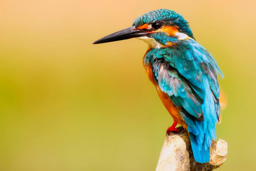

In [6]:
# fastdownload is a utility library by fast.ai for fast,simple,resumable downloads
# download_url is a helper function for downloading a file from an URL and saving it to a local file (more reliable than 'urllib.request.urlretrieve')
# dest is the file path here (it's a string) ;   if instead dest = 'images/bird.jpg' it would save the image under image/ folder
from fastdownload import download_url
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)                              #download_url also retries if interrupted
# urls is the list of all image URLs and urls[0] is the first image url, dest is the destination where file will be saved,
#    show_progress simply shows the percentage of progress(in the form of progress bar)
#    happened for downloading (False means progress bar is disabled)

# fastai.vision.all looks all tools for Computer vision and import * loads it in our notebook
# im = Image.open(dest) looks the image in dest and loads it in local RAM(here kaggle RAM)
# im.to_thumb(256,256) shrinks original image to a thumbnaill view (with aspect ratio protection shrinks keeping in mind the larger dimension like in 1920x1080 to 256x144)
from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

# to_thumb isn't there in official PIL but fastai used fastcore to "patch" it
# fastai uses PIL to open the file in local storage -> its a PIL Image now -> fastai takes PIL image and makes it a tensor -> model process those numbers and predict
# PILImage: PIL(Python Imaging Library, 'Pillow' now :> )
# type(im):(gives output->) PIL.JpegImagePlugin.JpegImageFile

#### Now let's try it with "forest photos"

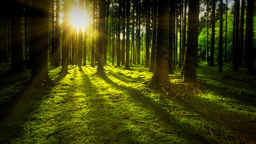

In [7]:
download_url(search_images('forest photos', max_images=1)[0], 'forest.jpg', show_progress=True)
Image.open('forest.jpg').to_thumb(256,256)

#### We got reasonable results from our search and now let's grab 200 examples of each of "bird" and "forest" photos, and save each group of photos to a different folder for training(the NN) purpose:

In [8]:
# searches is the tuple containg categories we need searching for
searches = 'forest','bird' #binary-classification dataset
path = Path('bird_or_not') #Path from pathlib automatically handles our path so we dont have to worry about '/' or '\'
from time import sleep  
#sleep prevents RateLimitException, DDG rate limits aggressively(see as scraping) and considers as too many request and blocks IP; 1-2s not enough, 5 is safe, 10 is very safe, 15+ search becomes exreme safe but slow

for o in searches:
    dest = (path/o)  #created sub-path like birs_or_not/forest or birs_or_not/bird
    dest.mkdir(exist_ok = True, parents = True)
    download_images(dest, urls = search_images(f'{o} photo'))
    sleep(10) # pause between searches to avoid overload server
    download_images(dest, urls = search_images(f'{o} sun photo'))    # purpose of adding 'sun' and 'shade' is to change lighting conditions to make our AI model a little more intelligent about real-world robustness
    sleep(10)
    download_images(dest, urls = search_images(f'{o} shade photo'))
    sleep(10)
    resize_images(path/o, max_size = 400, dest = path/o)   # resize_images is used for saving disk space as many images maybe of 4k/higher resolution and AI trains faster

# mkdir creates a new directory(dest.mkdir makes the directory at the designated destination)
#   parents = True: creates the parent folder if it DNE; 
#   exist_ok = True : its a "safety flag" if folder already exist code moves on and not crashes
#   result of dest.mkdir(exist_ok = True, parents = True): 
'''
    bird_or_not/
    ├── forest/
    └── bird/
'''
# why download_images instead of download_url?
'''
download_url downloads a single file while download_images downloads multiple images and auto-names it like 00001.jpg, 0002.jpg
generally download_url(url[0],dest) is used for testing purposes to see if the program is working, but crashes on broken URLs
download_images() downloads messy all kinds of images from internet, skips broken URL ones and corrupt images and auto-name files, basically dataset creation is the purpose here
final structure(example like):
bird_or_not/
├── forest/
│   ├── 0001.jpg       # 0s are used for padding here
│   ├── 0002.jpg
│   └── ...
└── bird/
    ├── 0001.jpg
    ├── 0002.jpg
    └── ...
    
'''
len((path/'bird').ls()) 
# To know how many images we got coz many are ghost images(lead to somewhere else where now site broken, duplicate images or maybe there werent enough images on internet of provided search)

279

In [22]:
print(len((path/'forest').ls()))
print(len((path/'bird').ls()))
len(path.ls()) # path is only 'bird_or_not' so len((path/'bird_or_not').ls) gives error

# Here max no of images isnt 400 its 600 3 search items '{o} photo', '{o} sun photo', '{o} sun photo'
# here let {o} is category which is either 'bird' or 'forest' 
# so total capacity is 3x200x2 = 1200 (while we get 266+279=545)

266
279


2

# Step 2: Train our model

#### Some Photos might not download correctly which could cause our training model to fail, so we'll remove them:

In [9]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed) # total no of broken images that were deleted, if these weren't deleted AI will stop training there and a giant red-error message will pop-out

# This "get_image_files(path)" fastai function get into the path directory and creates a list of all files
# verify_images(...) opens each and every image and check if its corrupt/broken and if it is then it adds that filepath to a list called 'failed'
# Here failed isn't a simple Python list but a Powerful L(...) object, .map() tells to take the next command and apply it to every single item in the list
# Path.unlink deletes the physical file from the drive


# len((path/'bird').ls()) #to know how many good images we got

2

#### To train a model, we'll need **Datablock**, which is an object that contains a *training set*(the images used to create a model) and a *validation set*(the images used to check the accuracy of a model - not used during training). In **fastai** we can create that easily using a **Datablock**, and view sample images from it:

"\nseed is used to fixate the same random images, \non using seed: everytime we use the same notebook we get the same training and testing images\nlet seed = 42 today i get image: A,C,E and tomm seed=42 i get image: A,C,E(not only 42 any number if today and tomm same i get same training and validation images)\nbut let seed = 12 today i get image: F,C,E and tomm seed=9 i get image: A,K,E(e.g.) and 42 is just a famous reference to a book that's it\n"

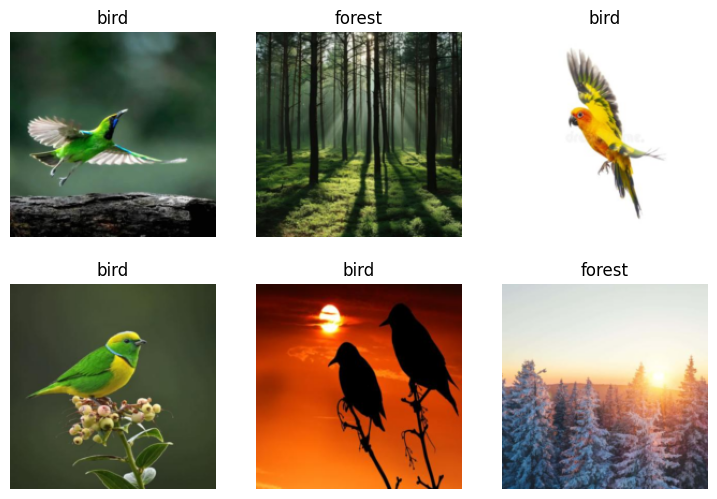

In [10]:
# In recent times the number of DL models is narrowed(ImageBlock and CategoryBlock on passing fastai chooses the model automatically)

# Datablock - blueprint(like recipe), DataLoaders - Actual data flowing into the model(like cooked food)
dls = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files, #basically same as get_x 
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),  #RandomSplitter(...) make a list of all image files, shuffles it and cuts dataset randomly as given train-test split
    get_y = parent_label,   # get_y is kind of question "where is the label" and parent_label is the "answer"(look at folder name in which file placed)
    item_tfms = [Resize(192, method='squish')] 
).dataloaders(path)

# NOTE: fastai willn't allow to trian a model unless you give validation set
# Resize used coz if one image 1000x1000 and another 100x200 AI willn't be able to read it as fixed linear layers(final layers in NN) 
#  and to use batch processing by GPUs (If lets say 64) and last feature matching lets say 'feather' or 'eye' roughly occupies same number of pixels

dls.show_batch(max_n = 6) # Ths random 6 images to check if the folder label is right or not before even training starts to avoid big-time errors
#and this max_n isnt batch size(bs) here batch size maybe 64 or anything else

# dataloaders(path) means "take the blueprint in DataBlock apply rules to data at path and give me ready-to-use PyTorch DataLoaders"


# blocks = (Imageblock, Categoryblock)    # Here the input(x) is an Image and output is a category/labels(y) 'bird' or 'forest'
# get_items = get_image_files looks inside the provided path and finds all the image files
#            (recurilvely search subfolders also and looks foe image extensions like .jpg, .png etc only and ignore other non-image formats)
# valid_pct = 0.2 means:  validation set - 20% and training set - 80%

'''
seed is used to fixate the same random images, 
on using seed: everytime we use the same notebook we get the same training and testing images
let seed = 42 today i get image: A,C,E and tomm seed=42 i get image: A,C,E(not only 42 any number if today and tomm same i get same training and validation images)
but let seed = 12 today i get image: F,C,E and tomm seed=9 i get image: A,K,E(e.g.) and 42 is just a famous reference to a book that's it
'''
# get_y = parent_label used to identify whether its a bird or forest from folder name file is placed in (e.g.: bird_or_not/bird/000001.jpg  → 'bird')
# item_tfms(item transformations) apply to every image for batch processing(GPU reuire every image in a batch same size for parallel processing)
#     Resize(192,method='squish') means it forces every image to be 192x192 without cropping, squish doesn't preserve aspect ratio so avoided in OCR, edical imaging etc.


# Dataloaders will feed the algorithm with bunch/batch of data(images here) at once
# This block is the brain of the data pipeline, this Datablock tells fastai how to transform raw files into something that "AI understands"

#### Now we're ready to train our model. The fasetest widely used Computer Vision model is **resnet18**. We can train it in a few minutes(CPU) or seconds(GPU).

In [13]:
'''
vision_learner is high-level function by fastai library to
1. Download the 'brain' i.e. "resnet18"
2. Chops of old head (generic layers)
3. Attach new head (last layers)
4. Freezes the body(general knowledge layers like colors,shapes etc.)
(Above are main 4 tasks other tasks are performed also like optimizer, loss function etc.)
'''
# learner is very-imp here it combines the model(the actual NN we're training) with the data(which we use for training)
learn = vision_learner(dls, resnet18, metrics=error_rate) #resnet18 is pretrained CNN architecture on 1.3 million ImageNet images
learn.fine_tune(3) 
# metric = error_rate defined percentage of what amount images were wrongly predicted, if its 0.05 then model is 95% accurate
#  (error_rate is displayed after each epoch)
# finetune it by running the pretrained model 3 times(no.of epochs here) to learn basics, understand details and polish performance to predict
# finetune 2 stages - 1. Train the head(freeze backbone), 2. Finetune whole model

# Finetune better coz 100,000 images and hours of computation time saved
# NOTE: no. of epochs is 3 here (but 4 are run 1st one run with freezing main body and trains only new layers)

epoch,train_loss,valid_loss,error_rate,time
0,0.829501,0.365931,0.102804,00:49


epoch,train_loss,valid_loss,error_rate,time
0,0.248976,0.320514,0.121495,01:07
1,0.180682,0.349876,0.121495,01:07
2,0.135497,0.282804,0.112150,01:06


#### **"Fine_tuning"** a model means that we're starting with a model someone else has trained using some other dataset(called the pretrained model), and adjusting the weights a little bit so that the model learns to recognise our particular dataset. In this case, the pretrained model was trained to recognize photos in *imagenet*(widely-used CV dataset with images covering 1000 categories)

In [14]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg')) 
print(f"This is a: {is_bird}.")
print(f"The probability it's a bird: {probs[0]:.4f}")

# loads a bird image from disk -> (apply trransform -> batch transform(tensor conversion) -> run through trained model -> convert model output to human readable form)
# Predict function have 3 things : 
#    1. The Predicted_Class(string): Class with highest score(human-readable)   # It catches the string either 'bird' or 'forest'
#    2. The Index(0 or 1 which we don't need here as we have name is_bird) so _ as a variable name is given to "ignore" a value
#    3. The Probabilities(List): A number between 0 and 1 to represent "how sure" is the model like [0.998,0.002]

# The _(index) thing is like for folder numbering whats after what if cat, dog, cow folders are placed in this order,
#    sort alphabetically cat-0, cow-1, dog-2 (Index starts at 0)

This is a: bird.
The probability it's a bird: 1.0000
